In [1]:
import os
import pandas as pd
from ORBIT import ProjectManager, load_config
import csv
import matplotlib.pyplot as plt

# Turn dataframe into list of tuples

In [2]:
def create_list_tuples_failure_rate_increases(df):
    percentage = df['Percentage'].to_list()
    increase = df['Average'].to_list()
    tuple_list = list()
   
    for i in range (0, len(increase)):
        tuple_list.append((percentage[i], increase[i]))

    return tuple_list

def create_list_tuples_failure_rate_increases_runs(df):
    percentage = df['Percentage'].to_list()
    increase = df['Annual OpEx per kW ($/kW)'].to_list()
    tuple_list = list()
   
    for i in range (0, len(increase)):
        tuple_list.append((percentage[i], increase[i]))

    return tuple_list



(0, 91.94762505)
[(0, 81.13976725), (5, 86.68331612), (10, 89.21271036), (15, 90.45388208), (20, 94.72420561)]


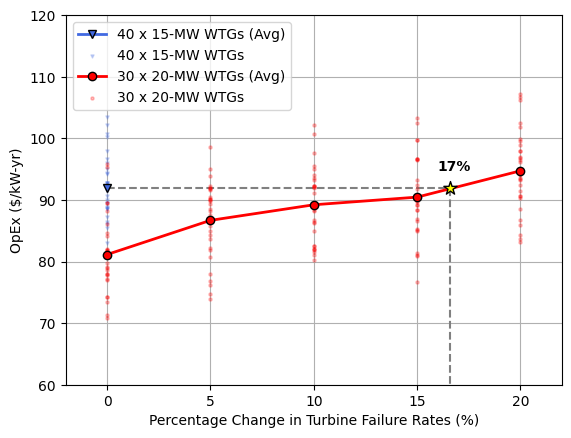

In [3]:
def plot_comparison_abs(MW_15_list, MW_20_list, MW_15_list_runs, MW_20_list_runs):

    MW_15_list = tuple(MW_15_list[2])
    
    print(MW_15_list)
    MW_20_list = list(MW_20_list[2:7])
    print(MW_20_list)
    
    x_val_15 = [MW_15_list[0]]
    y_val_15 = [MW_15_list[1]]

    x_val_20 = [x[0] for x in MW_20_list]
    y_val_20 = [x[1] for x in MW_20_list]

    x_val_15_runs = [x[0] for x in MW_15_list_runs]
    y_val_15_runs = [x[1] for x in MW_15_list_runs]

    x_val_20_runs = [x[0] for x in MW_20_list_runs]
    y_val_20_runs = [x[1] for x in MW_20_list_runs]
    
    #plt.scatter(x_val_15[-1], y_val_15[-1], color = "yellow", linewidth=1, marker = "*", edgecolor = "black", s = 200, zorder = 100)
    plt.plot(x_val_15, y_val_15, color = "royalblue", linewidth=2, marker = "v", zorder = 50, markeredgecolor="black")
    plt.scatter(x_val_15_runs, y_val_15_runs, color = "royalblue", marker = "v", zorder = 25, alpha = 0.25, s=5)
    plt.plot(x_val_20, y_val_20, color = "red", linewidth=2, marker = "o", zorder = 50, markeredgecolor="black")
    plt.scatter(x_val_20_runs, y_val_20_runs, color = "red", marker = "o", zorder = 25, alpha = 0.25, s=5)
    
    plt.legend(["40 x 15-MW WTGs (Avg)", "40 x 15-MW WTGs", "30 x 20-MW WTGs (Avg)", "30 x 20-MW WTGs"], fontsize = 10, loc = "upper left")
    #plt.plot([0, monopile_equalizer], [y_val_15_mon[0], y_val_15_mon[0]], "--", color = "grey")
    #plt.plot([0, turbine_equalizer], [y_val_15_tur[0], y_val_15_tur[0]], "--", color = "grey")
    #plt.fill_between([-30, 30], [-6.5 ,-6.5], [1 ,1], color='grey',alpha=0.25)
    #plt.plot([-30, 30], [1 ,1] , "--", color = "grey")
    #plt.plot([-30, 30], [-6.5 ,-6.5] , "--", color = "grey")
    plt.plot([0, 16.6], [y_val_15[0], y_val_15[0]] , "--", color = "grey")
    plt.plot([16.6, 16.6], [0, y_val_15[0]], "--", color = "grey")
    plt.scatter(16.6, y_val_15[0], color = "yellow", linewidth=1, marker = "*", edgecolor = "black", s = 100, zorder = 100)
    
    plt.text(17 - 1, y_val_15[0]*1.03, str(int(17))+"%", fontweight='bold')
    
    #plt.scatter(monopile_equalizer, y_val_15_mon[0], color = "yellow", linewidth=1, marker = "*", edgecolor = "black", s = 100, zorder = 100)
    #plt.scatter(turbine_equalizer, y_val_15_tur[0], color = "yellow", linewidth=1, marker = "*", edgecolor = "black", s = 100, zorder = 100)
    #plt.text(monopile_equalizer - 1.5, y_val_15_mon[0]*1.06, str(int(monopile_equalizer+0.5))+"%")
    #plt.text(3, 2, "Cost-Competitive", weight='bold', color = 'grey')
    plt.xlim((-2, 22))
    plt.ylim((60, 120))
    plt.ylabel('OpEx ($/kW-yr)')
    plt.xlabel('Percentage Change in Turbine Failure Rates (%)')
    plt.grid()
    plt.savefig("plots/OpEx_abs.svg")
    plt.savefig("plots/OpEx_abs.png")
    plt.show()


df_15_abs = pd.read_csv("data/15_MW_OpEx_absolute.csv")
df_15_abs_runs = pd.read_csv("data/15_MW_OpEx_absolute_runs.csv")
df_20_abs = pd.read_csv("data/20_MW_OpEx_absolute.csv")
df_20_abs_runs = pd.read_csv("data/20_MW_OpEx_absolute_runs.csv")
MW_15_list = create_list_tuples_failure_rate_increases(df_15_abs)
MW_20_list = create_list_tuples_failure_rate_increases(df_20_abs)
MW_15_list_runs = create_list_tuples_failure_rate_increases_runs(df_15_abs_runs)
MW_20_list_runs = create_list_tuples_failure_rate_increases_runs(df_20_abs_runs)



plot_comparison_abs(MW_15_list, MW_20_list, MW_15_list_runs, MW_20_list_runs)


In [10]:
value_1 = MW_15_list[2][1]
value_2 = MW_20_list[2][1]

print((value_2-value_1)/value_1)

-0.11754363197660421
